In [14]:
import torch

print(torch.__version__)

2.11.0+cpu


In [15]:
x = torch.tensor([
    [1.0, 2.0, 3.0],
    [4.0, 5.0, 6.0]
])

print(x)
print("Shape:", x.shape)
print("Data type:", x.dtype)

tensor([[1., 2., 3.],
        [4., 5., 6.]])
Shape: torch.Size([2, 3])
Data type: torch.float32


In [16]:
result = x @ x.T

print(result)
print("Shape:", result.shape)

tensor([[14., 32.],
        [32., 77.]])
Shape: torch.Size([2, 2])


In [17]:
print("Mean:", x.mean())
print("Sum:", x.sum())
print("Column sums:", x.sum(dim=0))
print("Row sums:", x.sum(dim=1))

Mean: tensor(3.5000)
Sum: tensor(21.)
Column sums: tensor([5., 7., 9.])
Row sums: tensor([ 6., 15.])


In [18]:
x = torch.tensor([
    [1.0, 2.0, 3.0],
    [4.0, 5.0, 6.0]
])

print(x)
print(x.shape)
print(x.dtype)

tensor([[1., 2., 3.],
        [4., 5., 6.]])
torch.Size([2, 3])
torch.float32


In [19]:
print(x @ x.T)
print(x.mean())
print(x.sum(dim=0))

tensor([[14., 32.],
        [32., 77.]])
tensor(3.5000)
tensor([5., 7., 9.])


In [20]:
w = torch.tensor([2.0], requires_grad=True)
x = torch.tensor([3.0])

y = w * x
loss = y ** 2

loss.backward()

print("w:", w)
print("Gradient:", w.grad)


w: tensor([2.], requires_grad=True)
Gradient: tensor([36.])


In [21]:
torch.manual_seed(0)

X = torch.randn(20, 2)

W1 = torch.randn(2, 8, requires_grad=True)
b1 = torch.zeros(8, requires_grad=True)

W2 = torch.randn(8, 1, requires_grad=True)
b2 = torch.zeros(1, requires_grad=True)

h = torch.relu(X @ W1 + b1)
out = h @ W2 + b2

loss = (out ** 2).mean()

loss.backward()

print("W1 gradient shape:", W1.grad.shape)
print("W1 gradient:", W1.grad)

W1 gradient shape: torch.Size([2, 8])
W1 gradient: tensor([[-8.2166e-01, -7.7488e-01,  4.7675e-01, -1.3239e+00, -3.2254e-02,
         -4.9069e-02, -8.5406e-04, -6.9263e-01],
        [-2.6756e+00,  1.5724e-01,  2.4801e-01, -1.8708e+00, -1.0503e-01,
          1.7903e-01,  5.2638e-03,  1.1515e+00]])


In [22]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

Xn, yn = make_moons(
    n_samples=500,
    noise=0.2,
    random_state=0
)

Xtr, Xva, ytr, yva = train_test_split(
    Xn, yn,
    test_size=0.25,
    random_state=0
)

def to_t(a):
    return torch.tensor(a, dtype=torch.float32)

Xtr, Xva = to_t(Xtr), to_t(Xva)

ytr = to_t(ytr).unsqueeze(1)
yva = to_t(yva).unsqueeze(1)

loader = DataLoader(
    TensorDataset(Xtr, ytr),
    batch_size=32,
    shuffle=True
)

model = nn.Sequential(
    nn.Linear(2, 16),
    nn.ReLU(),
    nn.Linear(16, 1)
)

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-1
)


In [23]:
for epoch in range(60):
    model.train()

    for bx, by in loader:
        optimizer.zero_grad()

        logits = model(bx)

        loss = criterion(logits, by)

        loss.backward()

        optimizer.step()

    if epoch % 10 == 0:
        model.eval()

        with torch.no_grad():
            tr = criterion(model(Xtr), ytr).item()
            va = criterion(model(Xva), yva).item()

        print(f"epoch {epoch:2d}  train {tr:.3f}  val {va:.3f}")

epoch  0  train 0.291  val 0.395
epoch 10  train 0.096  val 0.142
epoch 20  train 0.112  val 0.152
epoch 30  train 0.080  val 0.124
epoch 40  train 0.072  val 0.097
epoch 50  train 0.063  val 0.092


In [24]:
learning_rates = [1e-1, 1e-2, 1e-3]

for lr in learning_rates:
    print(f"\n===== Learning Rate: {lr} =====")

    # Create a fresh model for each experiment
    model = nn.Sequential(
        nn.Linear(2, 16),
        nn.ReLU(),
        nn.Linear(16, 1)
    )

    criterion = nn.BCEWithLogitsLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=lr
    )

    for epoch in range(60):
        model.train()

        for bx, by in loader:
            optimizer.zero_grad()

            logits = model(bx)
            loss = criterion(logits, by)

            loss.backward()
            optimizer.step()

    # Evaluate
    model.eval()

    with torch.no_grad():
        train_loss = criterion(model(Xtr), ytr).item()
        val_loss = criterion(model(Xva), yva).item()

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Validation Loss: {val_loss:.4f}")


===== Learning Rate: 0.1 =====
Train Loss: 0.0693
Validation Loss: 0.1188

===== Learning Rate: 0.01 =====
Train Loss: 0.0858
Validation Loss: 0.1279

===== Learning Rate: 0.001 =====
Train Loss: 0.2696
Validation Loss: 0.3120


In [25]:
# Experiment: Model Capacity

hidden_sizes = [8, 16, 64]

for hidden_size in hidden_sizes:
    print(f"\n===== Hidden Layer Size: {hidden_size} =====")

    model = nn.Sequential(
        nn.Linear(2, hidden_size),
        nn.ReLU(),
        nn.Linear(hidden_size, 1)
    )

    criterion = nn.BCEWithLogitsLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=1e-2
    )

    for epoch in range(60):
        model.train()

        for bx, by in loader:
            optimizer.zero_grad()

            logits = model(bx)
            loss = criterion(logits, by)

            loss.backward()
            optimizer.step()

    model.eval()

    with torch.no_grad():
        train_loss = criterion(model(Xtr), ytr).item()
        val_loss = criterion(model(Xva), yva).item()

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Validation Loss: {val_loss:.4f}")


===== Hidden Layer Size: 8 =====
Train Loss: 0.1210
Validation Loss: 0.1604

===== Hidden Layer Size: 16 =====
Train Loss: 0.2591
Validation Loss: 0.3395

===== Hidden Layer Size: 64 =====
Train Loss: 0.0653
Validation Loss: 0.1054


In [26]:
# Experiment: Dropout

dropout_rates = [0.0, 0.2]

for dropout_rate in dropout_rates:
    print(f"\n===== Dropout: {dropout_rate} =====")

    if dropout_rate == 0.0:
        model = nn.Sequential(
            nn.Linear(2, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )
    else:
        model = nn.Sequential(
            nn.Linear(2, 16),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(16, 1)
        )

    criterion = nn.BCEWithLogitsLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=1e-2
    )

    for epoch in range(60):
        model.train()

        for bx, by in loader:
            optimizer.zero_grad()

            logits = model(bx)
            loss = criterion(logits, by)

            loss.backward()
            optimizer.step()

    model.eval()

    with torch.no_grad():
        train_loss = criterion(model(Xtr), ytr).item()
        val_loss = criterion(model(Xva), yva).item()

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Validation Loss: {val_loss:.4f}")


===== Dropout: 0.0 =====
Train Loss: 0.0889
Validation Loss: 0.1306

===== Dropout: 0.2 =====
Train Loss: 0.2083
Validation Loss: 0.2640


In [32]:
import pandas as pd

url = "https://raw.githubusercontent.com/SaeidRostami/Customer_Churn/master/WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(url)

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print(df.head())

Dataset loaded successfully!
Shape: (7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport S

In [33]:
# Clean and prepare the Telco Churn dataset

# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

# Remove rows with missing values
df = df.dropna().copy()

# Remove customer ID because it is not a useful prediction feature
df = df.drop(columns=["customerID"])

# Convert target: No = 0, Yes = 1
df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

print("Shape after cleaning:", df.shape)
print("\nChurn distribution:")
print(df["Churn"].value_counts())

Shape after cleaning: (7032, 20)

Churn distribution:
Churn
0    5163
1    1869
Name: count, dtype: int64


In [34]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Churn"])
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 5625
Testing samples: 1407


In [35]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Identify categorical and numerical columns
categorical_cols = X_train.select_dtypes(include=["object"]).columns
numerical_cols = X_train.select_dtypes(exclude=["object"]).columns

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols)
    ]
)

# Fit only on training data, then transform both sets
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Training shape:", X_train_processed.shape)
print("Testing shape:", X_test_processed.shape)

Training shape: (5625, 45)
Testing shape: (1407, 45)


In [36]:
import torch
from torch.utils.data import TensorDataset, DataLoader

# Convert processed data to PyTorch tensors
X_train_tensor = torch.tensor(X_train_processed, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_processed, dtype=torch.float32)

y_train_tensor = torch.tensor(
    y_train.values,
    dtype=torch.float32
).reshape(-1, 1)

y_test_tensor = torch.tensor(
    y_test.values,
    dtype=torch.float32
).reshape(-1, 1)

# Create datasets
train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

# Create DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

print("Training tensor:", X_train_tensor.shape)
print("Testing tensor:", X_test_tensor.shape)
print("Training batches:", len(train_loader))
print("Testing batches:", len(test_loader))

Training tensor: torch.Size([5625, 45])
Testing tensor: torch.Size([1407, 45])
Training batches: 88
Testing batches: 22


In [37]:
import torch.nn as nn

input_size = X_train_tensor.shape[1]

model = nn.Sequential(
    nn.Linear(input_size, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 1)
)

print(model)
print("Input features:", input_size)

Sequential(
  (0): Linear(in_features=45, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=1, bias=True)
)
Input features: 45


In [38]:
import torch.optim as optim

# Calculate positive-class weight
num_negative = (y_train == 0).sum()
num_positive = (y_train == 1).sum()

pos_weight = torch.tensor(
    [num_negative / num_positive],
    dtype=torch.float32
)

print("Positive class weight:", pos_weight.item())

# Loss function with class weighting
criterion = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight
)

# Adam optimizer
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

Positive class weight: 2.7625417709350586


In [39]:
# Train the neural network

epochs = 50

for epoch in range(epochs):
    model.train()

    total_loss = 0

    for batch_X, batch_y in train_loader:

        # 1. Clear old gradients
        optimizer.zero_grad()

        # 2. Forward pass
        logits = model(batch_X)

        # 3. Calculate loss
        loss = criterion(logits, batch_y)

        # 4. Backpropagation
        loss.backward()

        # 5. Update weights
        optimizer.step()

        total_loss += loss.item()

    average_loss = total_loss / len(train_loader)

    if (epoch + 1) % 5 == 0:
        print(
            f"Epoch {epoch + 1:2d}/{epochs} "
            f"- Loss: {average_loss:.4f}"
        )

Epoch  5/50 - Loss: 0.7017
Epoch 10/50 - Loss: 0.6908
Epoch 15/50 - Loss: 0.6787
Epoch 20/50 - Loss: 0.6698
Epoch 25/50 - Loss: 0.6542
Epoch 30/50 - Loss: 0.6473
Epoch 35/50 - Loss: 0.6365
Epoch 40/50 - Loss: 0.6264
Epoch 45/50 - Loss: 0.6169
Epoch 50/50 - Loss: 0.6086


In [40]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

model.eval()

with torch.no_grad():
    logits = model(X_test_tensor)
    probabilities = torch.sigmoid(logits).squeeze()

# Convert probabilities to predictions
predictions = (probabilities >= 0.5).int().numpy()

y_true = y_test_tensor.squeeze().numpy()
y_prob = probabilities.numpy()

# Calculate metrics
accuracy = accuracy_score(y_true, predictions)
precision = precision_score(y_true, predictions)
recall = recall_score(y_true, predictions)
f1 = f1_score(y_true, predictions)
roc_auc = roc_auc_score(y_true, y_prob)

print("Telco Churn Neural Network Results")
print("----------------------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, predictions))

Telco Churn Neural Network Results
----------------------------------
Accuracy : 0.7264
Precision: 0.4908
Recall   : 0.7888
F1 Score : 0.6051
ROC-AUC  : 0.8210

Confusion Matrix:
[[727 306]
 [ 79 295]]


In [41]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

model.eval()

with torch.no_grad():
    logits = model(X_test_tensor)
    probabilities = torch.sigmoid(logits).squeeze()

predictions = (probabilities >= 0.5).int().numpy()

y_true = y_test_tensor.squeeze().numpy()
y_prob = probabilities.numpy()

accuracy = accuracy_score(y_true, predictions)
precision = precision_score(y_true, predictions)
recall = recall_score(y_true, predictions)
f1 = f1_score(y_true, predictions)
roc_auc = roc_auc_score(y_true, y_prob)

print("Telco Churn Neural Network Results")
print("----------------------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, predictions))

Telco Churn Neural Network Results
----------------------------------
Accuracy : 0.7264
Precision: 0.4908
Recall   : 0.7888
F1 Score : 0.6051
ROC-AUC  : 0.8210

Confusion Matrix:
[[727 306]
 [ 79 295]]


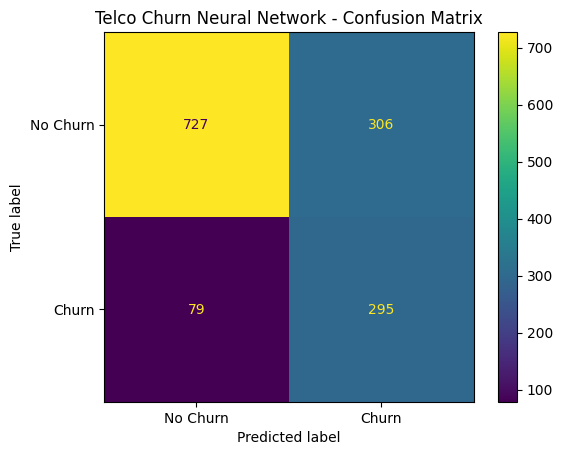

In [42]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_true, predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title("Telco Churn Neural Network - Confusion Matrix")
plt.show()

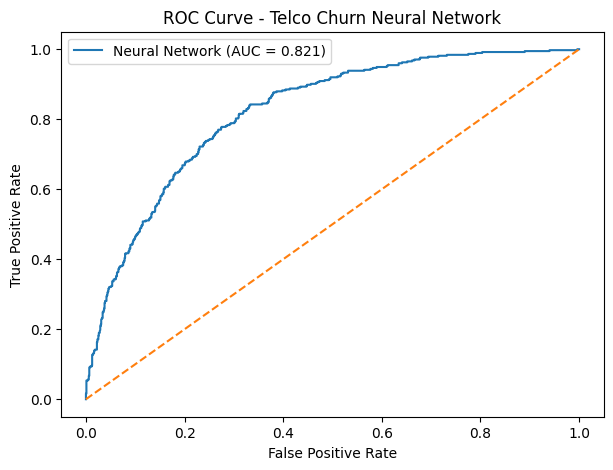

In [43]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_true, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Neural Network (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Telco Churn Neural Network")
plt.legend()
plt.show()

In [44]:
# Fresh model for tracking training and validation loss

model = nn.Sequential(
    nn.Linear(X_train_tensor.shape[1], 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 1)
)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

train_losses = []
val_losses = []

epochs = 50

for epoch in range(epochs):

    model.train()
    total_train_loss = 0

    for batch_X, batch_y in train_loader:

        optimizer.zero_grad()

        logits = model(batch_X)

        loss = criterion(logits, batch_y)

        loss.backward()

        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)

    model.eval()

    with torch.no_grad():
        val_logits = model(X_test_tensor)
        val_loss = criterion(
            val_logits,
            y_test_tensor
        ).item()

    train_losses.append(avg_train_loss)
    val_losses.append(val_loss)

    if (epoch + 1) % 5 == 0:
        print(
            f"Epoch {epoch + 1:2d} | "
            f"Train Loss: {avg_train_loss:.4f} | "
            f"Validation Loss: {val_loss:.4f}"
        )

Epoch  5 | Train Loss: 0.7019 | Validation Loss: 0.7369
Epoch 10 | Train Loss: 0.6926 | Validation Loss: 0.7307
Epoch 15 | Train Loss: 0.6766 | Validation Loss: 0.7426
Epoch 20 | Train Loss: 0.6628 | Validation Loss: 0.7511
Epoch 25 | Train Loss: 0.6481 | Validation Loss: 0.7617
Epoch 30 | Train Loss: 0.6357 | Validation Loss: 0.7772
Epoch 35 | Train Loss: 0.6252 | Validation Loss: 0.7814
Epoch 40 | Train Loss: 0.6114 | Validation Loss: 0.8055
Epoch 45 | Train Loss: 0.5963 | Validation Loss: 0.8279
Epoch 50 | Train Loss: 0.5863 | Validation Loss: 0.8318


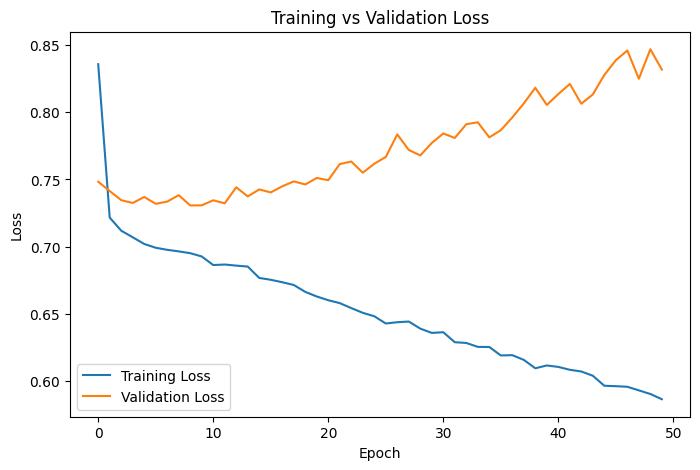

In [45]:
plt.figure(figsize=(8, 5))

plt.plot(
    train_losses,
    label="Training Loss"
)

plt.plot(
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

In [46]:
model.eval()

with torch.no_grad():
    logits = model(X_test_tensor)
    probabilities = torch.sigmoid(logits).squeeze()

predictions = (probabilities >= 0.5).int().numpy()

y_true = y_test_tensor.squeeze().numpy()
y_prob = probabilities.numpy()

final_accuracy = accuracy_score(y_true, predictions)
final_precision = precision_score(y_true, predictions)
final_recall = recall_score(y_true, predictions)
final_f1 = f1_score(y_true, predictions)
final_roc_auc = roc_auc_score(y_true, y_prob)

print("Final Neural Network Results")
print("----------------------------")
print(f"Accuracy : {final_accuracy:.4f}")
print(f"Precision: {final_precision:.4f}")
print(f"Recall   : {final_recall:.4f}")
print(f"F1 Score : {final_f1:.4f}")
print(f"ROC-AUC  : {final_roc_auc:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, predictions))

Final Neural Network Results
----------------------------
Accuracy : 0.7342
Precision: 0.5000
Recall   : 0.7540
F1 Score : 0.6013
ROC-AUC  : 0.8160

Confusion Matrix:
[[751 282]
 [ 92 282]]


In [47]:
results = pd.DataFrame({
    "Model": ["PyTorch Neural Network"],
    "Accuracy": [final_accuracy],
    "Precision": [final_precision],
    "Recall": [final_recall],
    "F1 Score": [final_f1],
    "ROC-AUC": [final_roc_auc]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,PyTorch Neural Network,0.734186,0.5,0.754011,0.601279,0.816019
